In [1]:
import os
import sys
sys.path.insert(
    0, os.path.abspath('../../')
)

import json
import yaml

from pathlib import Path
from rich.console import Console
from rich.table import Table

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
root_dir = Path("../../").resolve()
print("Root directory:", root_dir)

Root directory: /home/hgkahng/Workspaces/soft-prompt


## 1. Load Oracle Data

In [3]:
from typing import Union, Tuple

def load_oracle_sst_data(directory: Union[str, Path]
                         ) -> tuple[np.ndarray, np.ndarray]:
    
    _directory = Path(directory).resolve()

    X_train = np.load(_directory / "train.features.npy")
    y_train = np.load(_directory / "train.labels.npy")
    X_valid = np.load(_directory / "validation.features.npy")
    y_valid = np.load(_directory / "validation.labels.npy")
    X_test = np.load(_directory / "test.features.npy")
    y_test = np.load(_directory / "test.labels.npy")
    
    return X_train, y_train, X_valid, y_valid, X_test, y_test

oracle_embedding_dir = root_dir / "data/sst/embeddings/openai/text-embedding-3-small"
X_train, y_train, X_val, y_val, X_test, y_test = load_oracle_sst_data(oracle_embedding_dir)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(8544, 1536) (8544,)
(1101, 1536) (1101,)
(2210, 1536) (2210,)


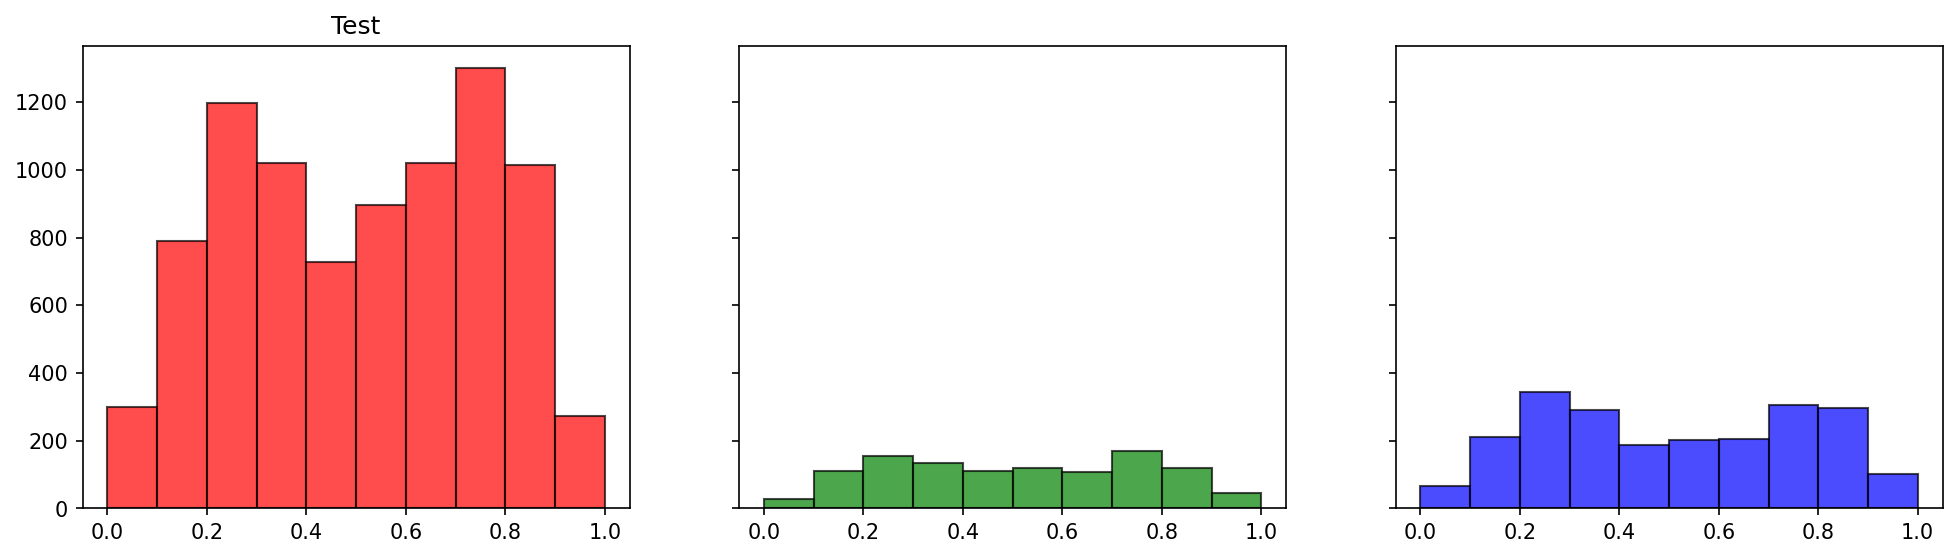

In [4]:
fig, axes = plt.subplots(1, 3, sharey=True, figsize=(16,4), dpi=150)
axes[0].hist(y_train, edgecolor='k', bins=np.arange(0, 1.1, 0.1), facecolor='r', alpha=.7)
axes[1].hist(y_val, edgecolor='k', bins=np.arange(0, 1.1, 0.1), facecolor='g', alpha=.7)
axes[2].hist(y_test, edgecolor='k', bins=np.arange(0, 1.1, 0.1), facecolor='b', alpha=.7)
axes[0].set_title("Train")
axes[0].set_title("Validation")
axes[0].set_title("Test")
plt.show(fig)

Load synthetic data

In [31]:
load_dir = root_dir / "results/sst/2025-05-05_13:17:51"  # hard
load_dir = root_dir / "results/sst/2025-05-05_12:45:20"  # soft
load_dir = root_dir / "results/sst/2025-05-08_21:23:34"  # hard + CoT
load_dir = root_dir / "results/sst/2025-05-08_18:21:16"  # soft + CoT
print("Model directory:", load_dir)
print(*os.listdir(load_dir), sep="\n")

Model directory: /home/hgkahng/Workspaces/soft-prompt/results/sst/2025-05-08_18:21:16
template.jsonl
embeddings
config.yaml
data.jsonl
template_formatted.txt


In [32]:
# Print configurations

with open(load_dir / 'config.yaml') as f:
    cfg = yaml.safe_load(f)

table = Table(title="Configuration(s)")
table.add_column("Name", justify="right", style="white", no_wrap=True)
table.add_column("Value", justify="left", style="cyan",)
_ = [table.add_row(k, str(v)) for k, v in cfg.items()]

console = Console()
console.print(table);

         Configuration(s)          
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃         Name ┃ Value            ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│   batch_size │ 50               │
│          cot │ True             │
│         data │ sst              │
│         hard │ False            │
│ log_interval │ 2                │
│   max_tokens │ 16384            │
│        model │ gemini-2.0-flash │
│ num_examples │ None             │
│  sample_size │ 20000            │
│  temperature │ 1.0              │
└──────────────┴──────────────────┘

In [33]:
with open(load_dir / 'template_formatted.txt') as f:
    template_example = "".join(f.readlines())

print(template_example)

system:
You are tasked with generating realistic movie review snippets to train a sentiment classifier.
Use a sentiment scale from 0 (negative) to 1 (positive)
Each should generally be between 10 and 50 words, usually a single sentence or a short phrase.
Use realistic language that one might find in a movie review.
Before writing your final answer, please think step-by-step.
Ensure that you MUST provide your step-by-step thinking process in the final output.

human:
Write a movie review with a sentiment score of 0.206.



In [34]:
with open(load_dir / "data.jsonl", "r") as f:
    data = [json.loads(line) for line in f]

print(len(data))

20049


In [35]:
data[0]

{'label': 0.829,
 'text': 'A surprisingly funny and heartwarming movie with great acting and an engaging plot. Highly recommended!',
 'reasoning': 'The movie was surprisingly funny and heartwarming. The acting was great and the plot was engaging.'}

In [36]:
labels = [d['label'] for d in data]
labels = np.array(labels)                  # soft vectors

hard_labels = (labels > 0.5).astype(int)
soft_labels = labels.copy()

print("Hard labels, shape:", hard_labels.shape)
print("Soft labels, shape:", soft_labels.shape)

Hard labels, shape: (20049,)
Soft labels, shape: (20049,)


In [37]:
embeddings = np.load(
    load_dir / "embeddings/openai/text-embedding-3-small/data.npy"
)
print(embeddings.shape)

(20049, 1536)


In [38]:
assert len(hard_labels) == embeddings.shape[0]
assert len(soft_labels) == embeddings.shape[0]

In [39]:
X_syn = embeddings.copy()
y_syn_hard = hard_labels.copy()
y_syn_soft = soft_labels.copy()

In [40]:
pd.Series(y_syn_hard).value_counts()

1    10098
0     9951
Name: count, dtype: int64

In [41]:
os.environ["TOKENIZERS_PARALLELISM"] = "false"

## Downstream classification performance

In [42]:
import numpy as np
import copy
from typing import Tuple, Dict, Union, List, Optional

# Assuming these are available in your environment as per your existing code
from softprompt.metrics.evaluator import BinaryEvaluator
from softprompt.algorithms.sklearn.linear_model import (
    SoftLogisticRegressionCV, GCELogisticRegressionCV
)
# Standard sklearn LogisticRegressionCV
from sklearn.linear_model import LogisticRegressionCV


def evaluate_logreg_cv_experiment(
    X_train_full: np.ndarray,
    y_train_full_probs: np.ndarray,  # Original training labels as probabilities
    X_test: np.ndarray,
    y_test_hard: np.ndarray,         # Test labels, already hard (0 or 1)
    subsample_size: int,
    model_variant: str,              # 'soft' or 'standard'
    Cs: Union[int, List[float], np.ndarray] = 10,
    cv_folds: int = 5,
    solver: str = 'lbfgs',
    max_iter_solver: int = 1000,
    n_jobs_cv: Optional[int] = 8,
    base_random_seed: int = 42,
    bootstrap: bool = True,
    n_trials: int = 50
) -> Tuple[Dict[str, List[float]], Dict[str, List[float]]]:
    """
    Evaluates either SoftLogisticRegressionCV or standard LogisticRegressionCV
    using subsampling or bootstrapping over multiple trials.

    Parameters
    ----------
    X_train_full : np.ndarray
        Full training feature matrix.
    y_train_full_probs : np.ndarray
        Full training labels as probabilities (e.g., for the positive class in binary).
        These will be converted to P_train for soft LR or hard labels for standard LR.
    X_test : np.ndarray
        Test feature matrix.
    y_test_hard : np.ndarray
        Test labels, hard-coded (0 or 1).
    subsample_size : int
        Number of samples to use for training in each trial.
    model_variant : str
        Specifies the logistic regression variant: 'soft' or 'standard'.
    Cs : Union[int, List[float], np.ndarray], default=10
        Cs parameter for the CV model.
    cv_folds : int, default=5
        Number of cross-validation folds.
    solver : str, default='lbfgs'
        Solver to use for the logistic regression model.
    max_iter_solver : int, default=1000
        Maximum iterations for the solver.
    n_jobs_cv : Optional[int], default=8
        Number of jobs for parallel processing in CV.
    base_random_seed : int, default=42
        Base seed for random number generation to ensure reproducibility across trials.
    bootstrap : bool, default=True
        If True, use bootstrapping (sampling with replacement). Otherwise, use subsampling
        without replacement.
    n_trials : int, default=50
        Number of trials (subsampling/bootstrap iterations) to run.

    Returns
    -------
    Tuple[Dict[str, List[float]], Dict[str, List[float]]]
        A tuple containing two dictionaries:
        1. tr_out_agg: Aggregated metrics (mean, std) on the full training set.
        2. te_out_agg: Aggregated metrics (mean, std) on the test set.
    """
    if X_train_full.shape[0] != len(y_train_full_probs):
        raise ValueError("X_train_full and y_train_full_probs must have the same number of samples.")
    if model_variant not in ['soft', 'standard', 'gce']:
        raise ValueError("model_variant must be 'soft' or 'standard'.")

    evaluator = BinaryEvaluator(threshold=0.5) # Assuming BinaryEvaluator is defined elsewhere
    
    # Initialize dictionaries to store metric arrays for each trial
    # The keys will be metric names from evaluator.metrics_to_compute
    # This assumes evaluator.metrics_to_compute is available and populated before this call
    if not hasattr(evaluator, 'metrics_to_compute') or not evaluator.metrics_to_compute:
        # Fallback if metrics_to_compute is not set, use a default or raise error
        # For demonstration, let's assume some common metrics if not available.
        # In a real scenario, BinaryEvaluator should define this.
        print("Warning: evaluator.metrics_to_compute not found or empty. Using default metrics for collection: ['accuracy', 'roc_auc']")
        default_metrics = ['accuracy', 'roc_auc'] # Example
        tr_metric_to_array = {m: np.empty(n_trials) for m in default_metrics}
    else:
        tr_metric_to_array = {m: np.empty(n_trials) for m in evaluator.metrics_to_compute}
    te_metric_to_array = copy.deepcopy(tr_metric_to_array)

    full_idx = np.arange(X_train_full.shape[0])
    
    # Convert full y_train_full_probs to hard labels for evaluation consistency
    y_train_full_hard_for_eval = (y_train_full_probs > 0.5).astype(int)

    for i in range(n_trials):
        current_trial_seed = base_random_seed + i
        rng = np.random.default_rng(current_trial_seed)

        # Get sub-sampled indices to use for training
        if bootstrap:
            subsample_idx = rng.choice(full_idx, size=subsample_size, replace=True)
        else:
            subsample_idx = rng.permutation(full_idx)[:subsample_size]

        X_train_subsample = X_train_full[subsample_idx]
        y_train_subsample_probs = y_train_full_probs[subsample_idx]

        # Fit model
        if model_variant == 'soft':
            lg = SoftLogisticRegressionCV(
                Cs=Cs, cv=cv_folds, solver=solver,
                max_iter=max_iter_solver, n_jobs=n_jobs_cv,
                random_state=current_trial_seed,
            )
            # Prepare P_train for soft labels (num_samples, num_classes)
            # Assuming binary classification where y_train_subsample_probs are probs of class 1
            if y_train_subsample_probs.ndim == 1:
                 P_train_fit = np.stack(
                    [1 - y_train_subsample_probs, y_train_subsample_probs], axis=1
                )
            elif y_train_subsample_probs.ndim == 2 and y_train_subsample_probs.shape[1] == 2:
                 P_train_fit = y_train_subsample_probs # Assume it's already [prob_class_0, prob_class_1]
            else:
                raise ValueError(
                    "y_train_subsample_probs must be 1D (probs for class 1)"
                    " or 2D with shape (n_samples, 2)."
                )

            lg.fit(X_train_subsample, P_train_fit);
        
        elif model_variant == 'gce':
            lg = GCELogisticRegressionCV(
                Cs=Cs, cv=cv_folds, solver=solver,
                max_iter=max_iter_solver, n_jobs=n_jobs_cv,
                random_state=current_trial_seed,
                q_gce=0.9,
            )
            # Prepare P_train for soft labels (num_samples, num_classes)
            # Assuming binary classification where y_train_subsample_probs are probs of class 1
            if y_train_subsample_probs.ndim == 1:
                 P_train_fit = np.stack(
                    [1 - y_train_subsample_probs, y_train_subsample_probs], axis=1
                )
            elif y_train_subsample_probs.ndim == 2 and y_train_subsample_probs.shape[1] == 2:
                 P_train_fit = y_train_subsample_probs # Assume it's already [prob_class_0, prob_class_1]
            else:
                raise ValueError(
                    "y_train_subsample_probs must be 1D (probs for class 1) "
                    "or 2D with shape (n_samples, 2)."
                )

            lg.fit(X_train_subsample, P_train_fit)

        else: # model_variant == 'standard'
            lg = LogisticRegressionCV(
                Cs=Cs, cv=cv_folds, solver=solver,
                max_iter=max_iter_solver, n_jobs=n_jobs_cv,
                random_state=current_trial_seed,
                penalty='l2',  # Assuming L2 penalty to align with SoftLogisticRegression
                scoring='neg_log_loss' # To align CV optimization goal with 'cross_entropy'
            )
            # Standard LogisticRegressionCV expects 1D hard labels for y
            y_train_fit_hard = (y_train_subsample_probs > 0.5).astype(int)
            lg.fit(X_train_subsample, y_train_fit_hard)

        # Evaluate on the full training set
        # The evaluator expects y_true as hard labels and y_prob as predicted probabilities
        tr_metrics_i = evaluator(
            y_true=y_train_full_hard_for_eval, # Hard labels from original full y_train
            y_prob=lg.predict_proba(X_train_full)
        )
        for m, v in tr_metrics_i.items():
            if m in tr_metric_to_array:
                 tr_metric_to_array[m][i] = v

        # Evaluate on the test set
        te_metrics_i = evaluator(
            y_true=y_test_hard, # y_test is already hard labels
            y_prob=lg.predict_proba(X_test)
        )
        for m, v in te_metrics_i.items():
            if m in te_metric_to_array:
                te_metric_to_array[m][i] = v
    
    # Aggregate metrics (train)
    tr_out_agg = {}
    for m, arr in tr_metric_to_array.items():
        if not np.all(np.isnan(arr)): # Ensure array is not all NaNs before mean/std
            tr_out_agg[m] = [np.nanmean(arr), np.nanstd(arr, ddof=1)]
        else:
            tr_out_agg[m] = [np.nan, np.nan]


    # Aggregate metrics (test)
    te_out_agg = {}
    for m, arr in te_metric_to_array.items():
        if not np.all(np.isnan(arr)):
            te_out_agg[m] = [np.nanmean(arr), np.nanstd(arr, ddof=1)]
        else:
            te_out_agg[m] = [np.nan, np.nan]

    return tr_out_agg, te_out_agg

`Standard`

In [30]:
N = len(X_train) # Changed from X_train to X_syn
ratios = (0.01, 0.05, 0.10, 0.25, 0.50, 1.00)
subsample_sizes = [int(N * r) for r in ratios]

# Select which model variant to run in this loop
# Options: 'soft' or 'standard' or 'gce'
current_model_variant = 'standard'

for i, subsample_size in enumerate(subsample_sizes):

    from rich.console import Console
    console = Console()
    console.print(f">> Model Variant: [bold yellow]{current_model_variant.upper()}[/bold yellow], "
          f"Subsample Ratio: {ratios[i]:.2f} (Size: {subsample_size:,})")

    # (optional) Convert y_test probabilities to hard labels for y_test_hard argument
    y_test_hard_labels = (y_test > 0.5).astype(int)

    tr_metrics, te_metrics = evaluate_logreg_cv_experiment(
        X_train_full=X_syn,
        y_train_full_probs=y_syn_soft,
        X_test=X_test,
        y_test_hard=y_test_hard_labels,
        subsample_size=subsample_size,
        model_variant=current_model_variant, 
        bootstrap=True,
        n_trials=50
    )

    from rich.table import Table
    table = Table(title=f"Metrics (r={ratios[i]:.2f})")
    table.add_column("Metric Name", style='cyan', no_wrap=True, justify='left')
    table.add_column("Train", style='blue', justify='center')
    table.add_column("Test", style='white', justify='center')
    for name in tr_metrics.keys():  # assuming that keys are identical
        tr_mean_, tr_std_ = tr_metrics[name]
        tr_metric_value_str = f"{tr_mean_:.4f} (± {tr_std_:.4f})"
        te_mean_, te_std_ = te_metrics[name]
        te_metric_value_str = f"{te_mean_:.4f} (± {te_std_:.4f})"
        table.add_row(
            name,
            tr_metric_value_str,
            te_metric_value_str,
        )
    console.print(table);

    console.print("-" * 50)

>> Model Variant: STANDARD, Subsample Ratio: 0.01 (Size: 85)

                   Metrics (r=0.01)                    
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Metric Name ┃       Train       ┃       Test        ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ accuracy    │ 1.0000 (± 0.0000) │ 0.8079 (± 0.0170) │
│ precision   │ 1.0000 (± 0.0000) │ 0.7427 (± 0.0321) │
│ recall      │ 1.0000 (± 0.0000) │ 0.9272 (± 0.0284) │
│ f1_score    │ 1.0000 (± 0.0000) │ 0.8237 (± 0.0088) │
│ roc_auc     │ 1.0000 (± 0.0000) │ 0.9237 (± 0.0019) │
│ auprc       │ 1.0000 (± 0.0000) │ 0.9235 (± 0.0021) │
│ ece         │ 0.0009 (± 0.0004) │ 0.1140 (± 0.0315) │
└─────────────┴───────────────────┴───────────────────┘

--------------------------------------------------

>> Model Variant: STANDARD, Subsample Ratio: 0.05 (Size: 427)

                   Metrics (r=0.05)                    
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Metric Name ┃       Train       ┃       Test        ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ accuracy    │ 1.0000 (± 0.0000) │ 0.8131 (± 0.0051) │
│ precision   │ 1.0000 (± 0.0000) │ 0.7467 (± 0.0099) │
│ recall      │ 1.0000 (± 0.0000) │ 0.9283 (± 0.0112) │
│ f1_score    │ 1.0000 (± 0.0000) │ 0.8275 (± 0.0028) │
│ roc_auc     │ 1.0000 (± 0.0000) │ 0.9246 (± 0.0010) │
│ auprc       │ 1.0000 (± 0.0000) │ 0.9244 (± 0.0012) │
│ ece         │ 0.0008 (± 0.0001) │ 0.1123 (± 0.0108) │
└─────────────┴───────────────────┴───────────────────┘

...

                   Metrics (r=0.50)                    
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Metric Name ┃       Train       ┃       Test        ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ accuracy    │ 1.0000 (± 0.0000) │ 0.8154 (± 0.0013) │
│ precision   │ 1.0000 (± 0.0000) │ 0.7519 (± 0.0029) │
│ recall      │ 1.0000 (± 0.0000) │ 0.9217 (± 0.0046) │
│ f1_score    │ 1.0000 (± 0.0000) │ 0.8282 (± 0.0010) │
│ roc_auc     │ 1.0000 (± 0.0000) │ 0.9247 (± 0.0003) │
│ auprc       │ 1.0000 (± 0.0000) │ 0.9245 (± 0.0003) │
│ ece         │ 0.0007 (± 0.0003) │ 0.1044 (± 0.0046) │
└─────────────┴───────────────────┴───────────────────┘

--------------------------------------------------

>> Model Variant: STANDARD, Subsample Ratio: 1.00 (Size: 8,544)

                   Metrics (r=1.00)                    
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Metric Name ┃       Train       ┃       Test        ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ accuracy    │ 1.0000 (± 0.0000) │ 0.8149 (± 0.0008) │
│ precision   │ 1.0000 (± 0.0000) │ 0.7494 (± 0.0018) │
│ recall      │ 1.0000 (± 0.0000) │ 0.9262 (± 0.0038) │
│ f1_score    │ 1.0000 (± 0.0000) │ 0.8285 (± 0.0008) │
│ roc_auc     │ 1.0000 (± 0.0000) │ 0.9244 (± 0.0002) │
│ auprc       │ 1.0000 (± 0.0000) │ 0.9243 (± 0.0002) │
│ ece         │ 0.0019 (± 0.0000) │ 0.1104 (± 0.0029) │
└─────────────┴───────────────────┴───────────────────┘

--------------------------------------------------

## Margin-based Filtering

In [43]:
console = Console()

margin_to_metrics = {}
margins = (0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30)

# Select which model variant to run in this loop
# Options: 'soft' or 'standard' or 'gce'
current_model_variant = 'standard'
console.rule(f"[bold blue]Logistic Regression Type: {current_model_variant}[/bold blue]")

for _, m in enumerate(margins):
    console.rule(f"[bold cyan]Margin: {m:.2f}[/bold cyan]")

    # Filter data based on margin using y_syn_soft (1D probabilities)
    margin_mask = \
        (pd.Series(y_syn_soft) <= (0.5 - m)) | \
        (pd.Series(y_syn_soft) >= (0.5 + m))
    effective_indices = np.where(margin_mask.values)[0]

    if len(effective_indices) == 0:
        console.print(f">> Effective pool size is 0 with margin = {m}. Skipping.")
        margin_to_metrics[m] = {'train': {}, 'test': {}} # Store empty results
        continue

    X_syn_filtered = X_syn[effective_indices]
    y_syn_soft_filtered = y_syn_soft[effective_indices] # This is 1D
    N_filtered = len(X_syn_filtered)
    console.print(f">> Effective pool size is {N_filtered:,} with margin = {m}")

    # Store metrics for this margin across different subsample ratios
    train_metrics_for_margin_all_ratios: Dict[str, List[List[float]]] = {}
    test_metrics_for_margin_all_ratios: Dict[str, List[List[float]]] = {}
    
    N = len(X_train)
    ratios = (0.01, 0.05, 0.10, 0.25, 0.50, 1.00)
    subsample_sizes = [int(N * r) for r in ratios]

    for i, subsample_size in enumerate(subsample_sizes):
        
        console.print(f"\t>> Model: [bold yellow]{current_model_variant.upper()}[/bold yellow], "
            f"Subsample Ratio: {ratios[i]:.2f} (Size: {subsample_size:,})")

        # Convert y_test probabilities to hard labels for y_test_hard argument
        y_test_hard_labels = (y_test > 0.5).astype(int)

        tr_metrics, te_metrics = evaluate_logreg_cv_experiment(
            X_train_full=X_syn_filtered,
            y_train_full_probs=y_syn_soft_filtered, # Pass the filtered 1D soft labels
            X_test=X_test,
            y_test_hard=y_test_hard_labels,
            subsample_size=subsample_size,
            model_variant=current_model_variant,
            bootstrap=True,
            n_trials=50, # Fewer trials for faster example run
        )
        
        # Store all metrics for this ratio
        for metric_name, (mean_val, std_val) in tr_metrics.items():
            if metric_name not in train_metrics_for_margin_all_ratios:
                train_metrics_for_margin_all_ratios[metric_name] = []
            train_metrics_for_margin_all_ratios[metric_name].append([mean_val, std_val])
        
        for metric_name, (mean_val, std_val) in te_metrics.items():
            if metric_name not in test_metrics_for_margin_all_ratios:
                test_metrics_for_margin_all_ratios[metric_name] = []
            test_metrics_for_margin_all_ratios[metric_name].append([mean_val, std_val])

        from rich.table import Table
        table = Table(title=f"Metrics (m={m:.2f}, r={ratios[i]:.2f})")
        table.add_column("Metric Name", style='cyan', no_wrap=True, justify='left')
        table.add_column("Train", style='blue', justify='center')
        table.add_column("Test", style='white', justify='center')
        for name in tr_metrics.keys():
            tr_mean_, tr_std_ = tr_metrics[name]
            tr_metric_value_str = f"{tr_mean_:.4f} (± {tr_std_:.4f})"
            te_mean_, te_std_ = te_metrics[name]
            te_metric_value_str = f"{te_mean_:.4f} (± {te_std_:.4f})"
            table.add_row(
                name,
                tr_metric_value_str,
                te_metric_value_str,
            )
        console.print(table);

    margin_to_metrics[m] = {
        'train': train_metrics_for_margin_all_ratios,
        'test': test_metrics_for_margin_all_ratios,
    }

    console.print("-" * 50)

─────────────────────────────────────── Logistic Regression Type: standard ────────────────────────────────────────

────────────────────────────────────────────────── Margin: 0.00 ───────────────────────────────────────────────────

>> Effective pool size is 20,049 with margin = 0.0

>> Model: STANDARD, Subsample Ratio: 0.01 (Size: 85)

               Metrics (m=0.00, r=0.01)                
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Metric Name ┃       Train       ┃       Test        ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ accuracy    │ 0.9902 (± 0.0028) │ 0.7556 (± 0.0322) │
│ precision   │ 0.9926 (± 0.0036) │ 0.6817 (± 0.0454) │
│ recall      │ 0.9879 (± 0.0072) │ 0.9433 (± 0.0425) │
│ f1_score    │ 0.9902 (± 0.0028) │ 0.7892 (± 0.0174) │
│ roc_auc     │ 0.9995 (± 0.0001) │ 0.9028 (± 0.0062) │
│ auprc       │ 0.9995 (± 0.0001) │ 0.8939 (± 0.0077) │
│ ece         │ 0.0089 (± 0.0057) │ 0.1760 (± 0.0502) │
└─────────────┴───────────────────┴───────────────────┘

...

>> Model: STANDARD, Subsample Ratio: 0.50 (Size: 4,272)

               Metrics (m=0.30, r=0.50)                
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Metric Name ┃       Train       ┃       Test        ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ accuracy    │ 1.0000 (± 0.0000) │ 0.8486 (± 0.0018) │
│ precision   │ 1.0000 (± 0.0000) │ 0.8440 (± 0.0115) │
│ recall      │ 1.0000 (± 0.0000) │ 0.8425 (± 0.0146) │
│ f1_score    │ 1.0000 (± 0.0000) │ 0.8431 (± 0.0024) │
│ roc_auc     │ 1.0000 (± 0.0000) │ 0.9294 (± 0.0004) │
│ auprc       │ 1.0000 (± 0.0000) │ 0.9286 (± 0.0005) │
│ ece         │ 0.0008 (± 0.0003) │ 0.0247 (± 0.0043) │
└─────────────┴───────────────────┴───────────────────┘

>> Model: STANDARD, Subsample Ratio: 1.00 (Size: 8,544)

               Metrics (m=0.30, r=1.00)                
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Metric Name ┃       Train       ┃       Test        ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ accuracy    │ 1.0000 (± 0.0000) │ 0.8488 (± 0.0013) │
│ precision   │ 1.0000 (± 0.0000) │ 0.8445 (± 0.0034) │
│ recall      │ 1.0000 (± 0.0000) │ 0.8418 (± 0.0063) │
│ f1_score    │ 1.0000 (± 0.0000) │ 0.8431 (± 0.0019) │
│ roc_auc     │ 1.0000 (± 0.0000) │ 0.9297 (± 0.0002) │
│ auprc       │ 1.0000 (± 0.0000) │ 0.9290 (± 0.0003) │
│ ece         │ 0.0028 (± 0.0002) │ 0.0466 (± 0.0021) │
└─────────────┴───────────────────┴───────────────────┘

--------------------------------------------------